In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [2]:
pd.set_option('display.max_columns', None)

1. Data Loading and Preprocessing

In [3]:
# Load Data
train_file_path = 'Train.csv'
test_file_path = 'Test.csv'

df = pd.read_csv(train_file_path, sep=',', low_memory=False)
df_test = pd.read_csv(test_file_path, sep=',', low_memory=False)

In [4]:
# Make preprocessing rerun-safe in the same kernel
df = df.drop(columns=['Object_Name'], errors='ignore')
df_test = df_test.drop(columns=['Object_Name'], errors='ignore')
df['Timestamp'] = df['Timestamp'].fillna(" ")
df_test['Timestamp'] = df_test['Timestamp'].fillna(" ")

# Normalize all *_Py columns by participant-specific median head height
py_cols = [c for c in df.columns if '_Py' in c]
df_head_median = df.groupby('target_feature')['Head_Py'].transform('median')
df_test_head_median = df_test.groupby('target_feature')['Head_Py'].transform('median')
df[py_cols] = df[py_cols].div(df_head_median, axis=0)
df_test[py_cols] = df_test[py_cols].div(df_test_head_median, axis=0)

df_X = df.drop(['Timestamp', 'target_feature'], axis=1, errors='ignore')
df_X.fillna(0, inplace=True)

features = df_X.drop(['Frame', 'Time'], axis=1, errors='ignore')
feature_columns = features.columns

2. Data Exploration & Visualization

SAMPLE LENGTH ANALYSIS

Samples per participant:
target_feature
P01      8820
P02    131760
P03     71835
P04     26715
P05     33690
P06     47070
P07    167970
P08     14061
P09     39600
P10     33270
dtype: int64

Total samples: 574791
Mean samples per participant: 57479.1
Std samples per participant: 52399.4


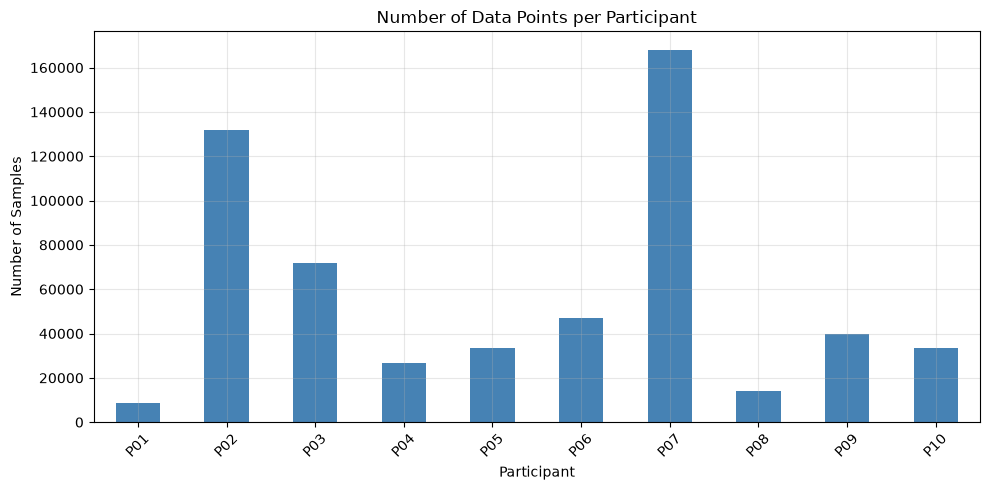

In [5]:
# 2.1 Sample Length Distribution
print("=" * 60)
print("SAMPLE LENGTH ANALYSIS")
print("=" * 60)

sample_lengths = df.groupby('target_feature').size()
print(f"\nSamples per participant:\n{sample_lengths}")
print(f"\nTotal samples: {len(df)}")
print(f"Mean samples per participant: {sample_lengths.mean():.1f}")
print(f"Std samples per participant: {sample_lengths.std():.1f}")

# Plot sample lengths
plt.figure(figsize=(10, 5))
sample_lengths.plot(kind='bar', color='steelblue')
plt.title('Number of Data Points per Participant')
plt.xlabel('Participant')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

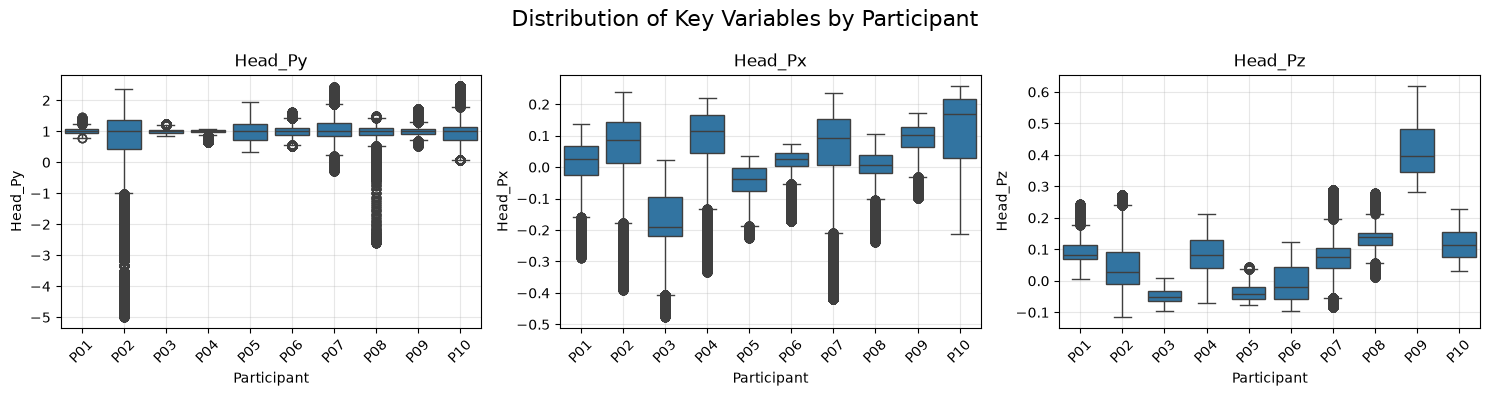

In [6]:
# 2.2 Boxplots of Key Variables (first 3 only)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribution of Key Variables by Participant', fontsize=16)

key_vars = ['Head_Py', 'Head_Px', 'Head_Pz']
available_vars = [var for var in key_vars if var in df.columns][:3]

for idx, var in enumerate(available_vars):
    ax = axes[idx]
    sns.boxplot(data=df, x='target_feature', y=var, ax=ax)
    ax.set_title(var)
    ax.set_xlabel('Participant')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


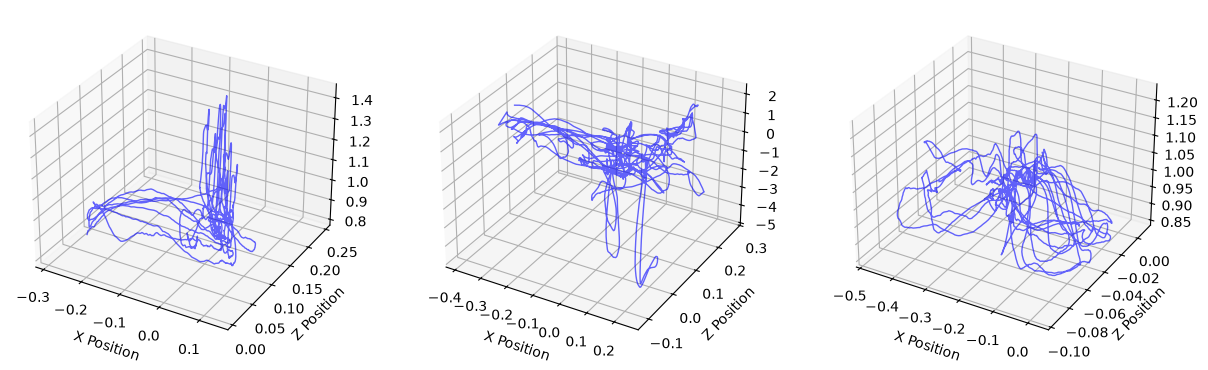

In [7]:
# Movement trajectories
participants = df['target_feature'].unique()[:3]

fig = plt.figure(figsize=(15, 5))

for idx, participant in enumerate(participants, 1):
    ax = fig.add_subplot(1, 3, idx, projection='3d')
    participant_data = df[df['target_feature'] == participant]
    
    if all(col in df.columns for col in ['Head_Px', 'Head_Pz', 'Head_Py']):
        ax.plot(participant_data['Head_Px'], 
                participant_data['Head_Pz'], 
                participant_data['Head_Py'], 
                label='Head', alpha=0.6, linewidth=1, color='blue')
    
    if all(col in df.columns for col in ['RightHand_Px', 'RightHand_Pz', 'RightHand_Py']):
        ax.plot(participant_data['RightHand_Px'], 
                participant_data['RightHand_Pz'], 
                participant_data['RightHand_Py'], 
                label='Right Hand', alpha=0.6, linewidth=1, color='red')
    
    ax.set_xlabel('X Position')
    ax.set_ylabel('Z Position')

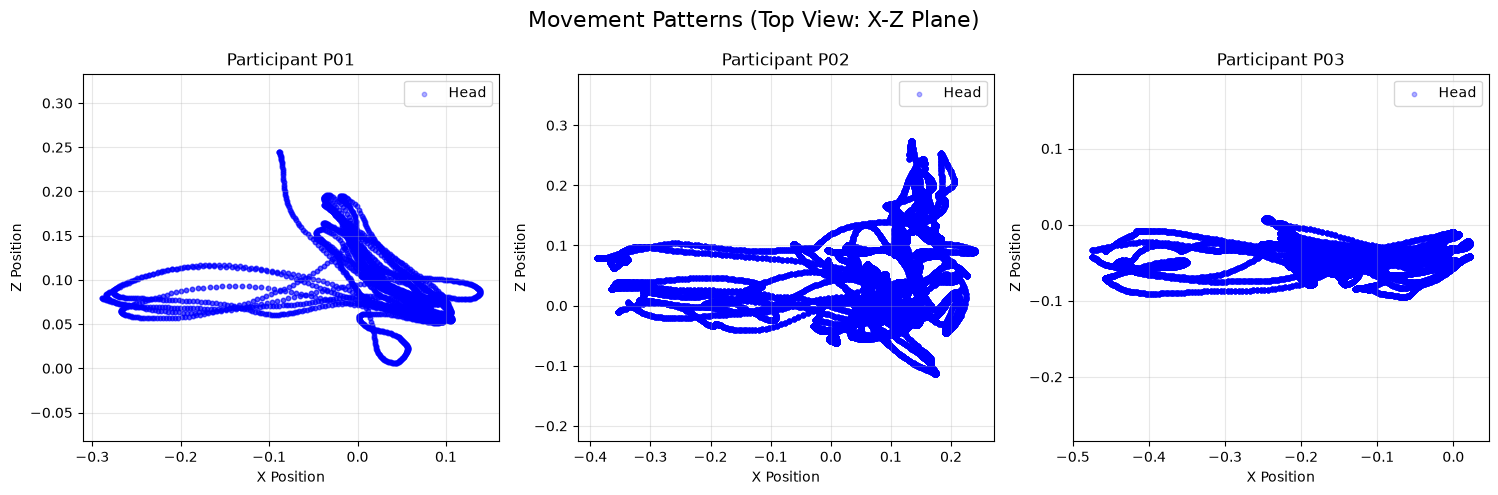

In [8]:
# 2.4 2D Movement Patterns (Top View)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Movement Patterns (Top View: X-Z Plane)', fontsize=16)

for idx, participant in enumerate(participants):
    ax = axes[idx]
    participant_data = df[df['target_feature'] == participant]
    
    if all(col in df.columns for col in ['Head_Px', 'Head_Pz']):
        ax.scatter(participant_data['Head_Px'], participant_data['Head_Pz'], 
                  alpha=0.3, s=10, label='Head', c='blue')
    
    if all(col in df.columns for col in ['RightHand_Px', 'RightHand_Pz']):
        ax.scatter(participant_data['RightHand_Px'], participant_data['RightHand_Pz'], 
                  alpha=0.3, s=10, label='Right Hand', c='red')
    
    ax.set_xlabel('X Position')
    ax.set_ylabel('Z Position')
    ax.set_title(f'Participant {participant}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axis('equal')

plt.tight_layout()
plt.show()

3. Preprocessing (Feature Extraction)

In [9]:
def process_data(dataframe):
  dataframe = dataframe.copy()

  # Build repetition IDs per participant without groupby-apply (pandas 3 safe).
  is_marker = dataframe['Timestamp'].astype(str).str.contains('SessionStarted', na=False)
  prev_marker = is_marker.groupby(dataframe['target_feature']).shift(1).fillna(False)
  rising_edge = is_marker & (~prev_marker)
  dataframe['repetition_id'] = rising_edge.groupby(dataframe['target_feature']).cumsum()
  dataframe = dataframe[dataframe['repetition_id'] > 0]

  features = []
  labels = []
  grouped = dataframe.groupby(['target_feature', 'repetition_id'])

  for participant, group in grouped:
      sample_features = []
      for col in feature_columns:
          if col in group.columns:
              series = group[col]
              sample_features.extend([series.min(), series.max(), series.mean(), series.std()])
          else:
              sample_features.extend([0, 0, 0, 0])
      features.append(sample_features)
      labels.append(participant[0])

  return features, labels


4. Model Training & Evaluation

In [10]:
print("Processing Training Data...")
X_train_list, y_train_list = process_data(df)

print("Processing Testing Data...")
X_test_list, y_test_list = process_data(df_test)
X_train = np.nan_to_num(X_train_list)
X_test = np.nan_to_num(X_test_list)

Processing Training Data...
Processing Testing Data...


In [11]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_list)
y_test_encoded = le.transform(y_test_list)

In [12]:
# Model Definition
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, min_samples_split=5, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6, subsample=0.8, eval_metric='logloss', random_state=42)
}


--- Model Evaluation Results ---

Training Decision Tree...
Accuracy: 88.65%

--- Classification Report ---
              precision    recall  f1-score   support

         P01       1.00      1.00      1.00         3
         P02       1.00      0.07      0.12        15
         P03       1.00      1.00      1.00        15
         P04       1.00      0.93      0.97        15
         P05       0.94      1.00      0.97        15
         P06       0.94      1.00      0.97        15
         P07       1.00      1.00      1.00        30
         P08       1.00      1.00      1.00         3
         P09       1.00      1.00      1.00        15
         P10       0.50      0.93      0.65        15

    accuracy                           0.89       141
   macro avg       0.94      0.89      0.87       141
weighted avg       0.93      0.89      0.86       141



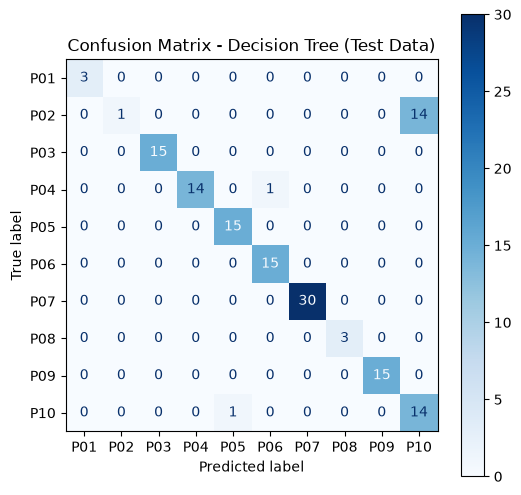

Training Random Forest...
Accuracy: 90.07%

--- Classification Report ---
              precision    recall  f1-score   support

         P01       1.00      1.00      1.00         3
         P02       1.00      0.07      0.12        15
         P03       1.00      1.00      1.00        15
         P04       1.00      1.00      1.00        15
         P05       1.00      1.00      1.00        15
         P06       1.00      1.00      1.00        15
         P07       1.00      1.00      1.00        30
         P08       1.00      1.00      1.00         3
         P09       1.00      1.00      1.00        15
         P10       0.52      1.00      0.68        15

    accuracy                           0.90       141
   macro avg       0.95      0.91      0.88       141
weighted avg       0.95      0.90      0.87       141



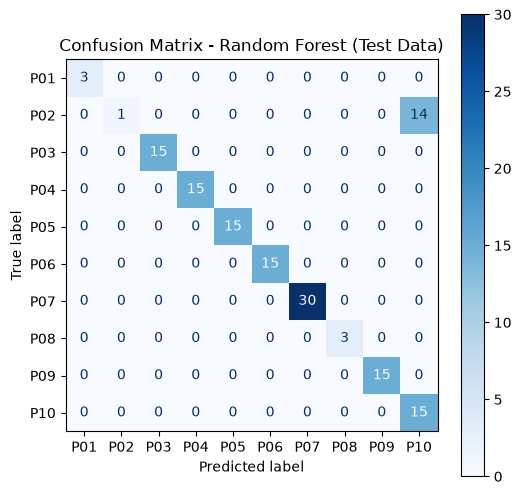

Training Gradient Boosting...
Accuracy: 85.11%

--- Classification Report ---
              precision    recall  f1-score   support

         P01       1.00      0.67      0.80         3
         P02       0.00      0.00      0.00        15
         P03       1.00      1.00      1.00        15
         P04       1.00      0.93      0.97        15
         P05       0.94      1.00      0.97        15
         P06       1.00      0.93      0.97        15
         P07       0.61      1.00      0.76        30
         P08       1.00      0.33      0.50         3
         P09       1.00      1.00      1.00        15
         P10       0.93      0.93      0.93        15

    accuracy                           0.85       141
   macro avg       0.85      0.78      0.79       141
weighted avg       0.80      0.85      0.81       141



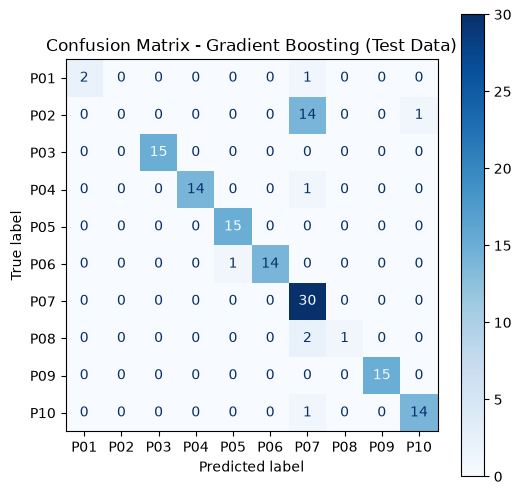

Training XGBoost...
Accuracy: 88.65%

--- Classification Report ---
              precision    recall  f1-score   support

         P01       1.00      1.00      1.00         3
         P02       1.00      0.07      0.12        15
         P03       1.00      1.00      1.00        15
         P04       1.00      1.00      1.00        15
         P05       0.94      1.00      0.97        15
         P06       1.00      0.93      0.97        15
         P07       1.00      1.00      1.00        30
         P08       0.75      1.00      0.86         3
         P09       1.00      0.93      0.97        15
         P10       0.52      1.00      0.68        15

    accuracy                           0.89       141
   macro avg       0.92      0.89      0.86       141
weighted avg       0.94      0.89      0.86       141



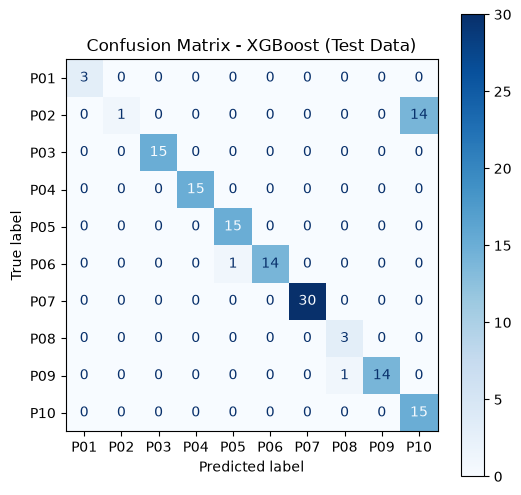

In [13]:
results = []
confusion_matrices = {}

print("\n--- Model Evaluation Results ---\n")

for name, clf in models.items():
    print(f"Training {name}...")
    
    clf.fit(X_train, y_train_encoded)
    predictions_encoded = clf.predict(X_test)
    predictions_strings = le.inverse_transform(predictions_encoded)
    acc = accuracy_score(y_test_list, predictions_strings)
    print(f"Accuracy: {acc * 100:.2f}%")

    print("\n--- Classification Report ---")
    print(classification_report(
        y_test_list,
        predictions_strings,
        labels=le.classes_,
        target_names=le.classes_,
        zero_division=0
    ))

    cm = confusion_matrix(y_test_list, predictions_strings, labels=le.classes_)
    confusion_matrices[name] = cm
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
    plt.title(f'Confusion Matrix - {name} (Test Data)')
    plt.show()

In [14]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

X_all = np.vstack([X_train, X_test])
y_all = np.concatenate([y_train_encoded, y_test_encoded])

print(f"\nDataset: {len(y_all)} samples, {len(set(y_all))} participants")
print(f"Features: {X_all.shape[1]} (40 sensors x 4 statistics)")
print(f"Evaluation: 3-Fold Stratified Cross-Validation\n")
final_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=3,
        max_features='sqrt',
        random_state=42
    ),
    'K-Nearest Neighbors': KNeighborsClassifier(
        n_neighbors=5,
        weights='distance',
        metric='euclidean'
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        eval_metric='logloss',
        random_state=42
    ),
    'Logistic Regression': make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=5000,
            C=1.0,
            solver='lbfgs',
            random_state=42
        )
    )
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("-" * 60)
print("Model Performance (3-Fold Cross-Validation):")
print("-" * 60)

results_summary = []
for name, model in final_models.items():
    scores = cross_val_score(model, X_all, y_all, cv=cv, scoring='accuracy')
    mean_score = scores.mean()
    std_score = scores.std()

    print(f"\n{name}:")
    print(f"  Accuracy: {mean_score*100:.2f}% (+/-{std_score*100:.2f}%)")
    print(f"  Fold scores: {[f'{s*100:.2f}%' for s in scores]}")

    results_summary.append({
        'Model': name,
        'Mean Accuracy': f"{mean_score*100:.2f}%",
        'Std Dev': f"+/-{std_score*100:.2f}%"
    })

print("\n" + "=" * 60)
print("SUMMARY TABLE")
print("=" * 60)
for result in results_summary:
    print(f"{result['Model']:<25} {result['Mean Accuracy']:>10} {result['Std Dev']:>10}")


Dataset: 579 samples, 10 participants
Features: 160 (40 sensors x 4 statistics)
Evaluation: 3-Fold Stratified Cross-Validation

------------------------------------------------------------
Model Performance (3-Fold Cross-Validation):
------------------------------------------------------------

Random Forest:
  Accuracy: 99.31% (+/-0.49%)
  Fold scores: ['98.96%', '100.00%', '98.96%']

K-Nearest Neighbors:
  Accuracy: 95.34% (+/-0.42%)
  Fold scores: ['95.85%', '94.82%', '95.34%']

XGBoost:
  Accuracy: 98.45% (+/-0.42%)
  Fold scores: ['98.96%', '97.93%', '98.45%']

Logistic Regression:
  Accuracy: 98.79% (+/-0.49%)
  Fold scores: ['98.45%', '99.48%', '98.45%']

SUMMARY TABLE
Random Forest                 99.31%   +/-0.49%
K-Nearest Neighbors           95.34%   +/-0.42%
XGBoost                       98.45%   +/-0.42%
Logistic Regression           98.79%   +/-0.49%


## Best Models Visualization

DETAILED VISUALIZATION FOR BEST MODELS

Random Forest:
  Fold 1: 98.96%
  Fold 2: 100.00%
  Fold 3: 98.96%

K-Nearest Neighbors:
  Fold 1: 95.85%
  Fold 2: 94.82%
  Fold 3: 95.34%


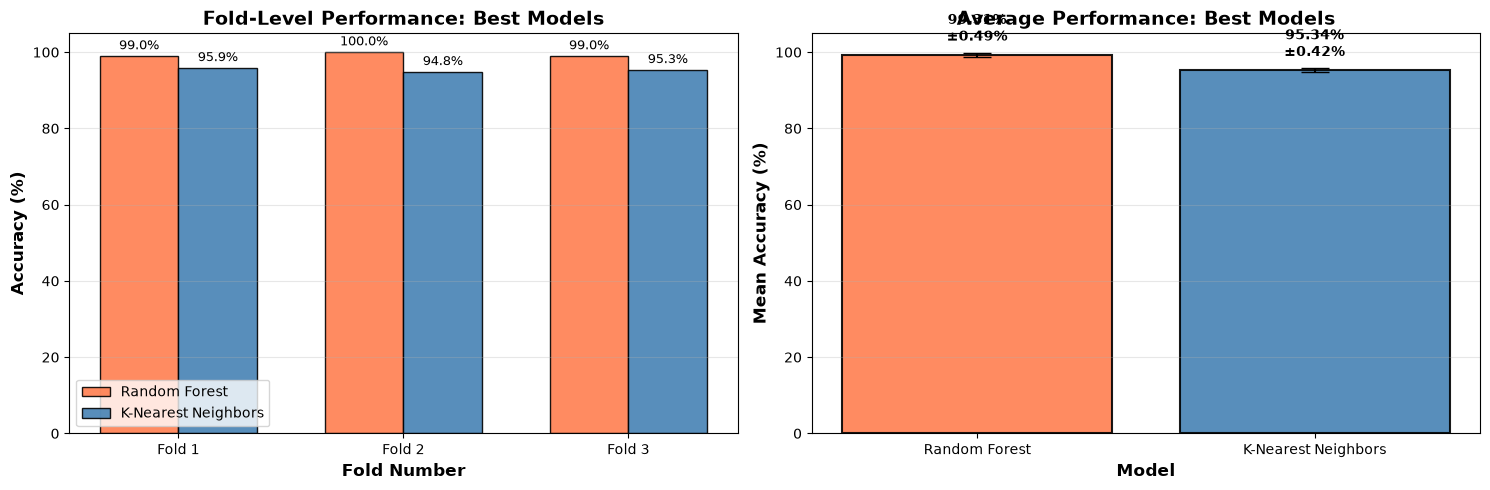

In [15]:
from sklearn.model_selection import cross_validate

print("=" * 60)
print("DETAILED VISUALIZATION FOR BEST MODELS")
print("=" * 60)

best_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=3,
        max_features='sqrt',
        random_state=42
    ),
    'K-Nearest Neighbors': KNeighborsClassifier(
        n_neighbors=5,
        weights='distance',
        metric='euclidean'
    )
}

fold_results = {name: [] for name in best_models.keys()}

cv_splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for name, model in best_models.items():
    cv_results = cross_validate(model, X_all, y_all, cv=cv_splitter, 
                                scoring='accuracy', return_train_score=True)
    fold_results[name] = cv_results['test_score']
    print(f"\n{name}:")
    for fold_idx, score in enumerate(cv_results['test_score'], 1):
        print(f"  Fold {fold_idx}: {score*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax1 = axes[0]
x_pos = np.arange(3)
width = 0.35

rf_scores = fold_results['Random Forest'] * 100
knn_scores = fold_results['K-Nearest Neighbors'] * 100

bars1 = ax1.bar(x_pos - width/2, rf_scores, width, label='Random Forest', 
                color='coral', alpha=0.9, edgecolor='black')
bars2 = ax1.bar(x_pos + width/2, knn_scores, width, label='K-Nearest Neighbors', 
                color='steelblue', alpha=0.9, edgecolor='black')

ax1.set_xlabel('Fold Number', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Fold-Level Performance: Best Models', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(['Fold 1', 'Fold 2', 'Fold 3'])
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim([0, 105])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                 f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

ax2 = axes[1]
model_names_best = list(best_models.keys())
mean_scores = [fold_results[name].mean() * 100 for name in model_names_best]
std_scores = [fold_results[name].std() * 100 for name in model_names_best]

bars = ax2.bar(range(len(model_names_best)), mean_scores, 
               yerr=std_scores, capsize=10, 
               color=['coral', 'steelblue'], alpha=0.9, 
               edgecolor='black', linewidth=1.5)

ax2.set_xlabel('Model', fontsize=12, fontweight='bold')
ax2.set_ylabel('Mean Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Average Performance: Best Models', fontsize=14, fontweight='bold')
ax2.set_xticks(range(len(model_names_best)))
ax2.set_xticklabels(model_names_best, rotation=0)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim([0, 105])

# Add value labels
for i, (mean, std) in enumerate(zip(mean_scores, std_scores)):
    ax2.text(i, mean + std + 2, f'{mean:.2f}%\n±{std:.2f}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


CONFUSION MATRIX: RANDOM FOREST (3-FOLD CV)


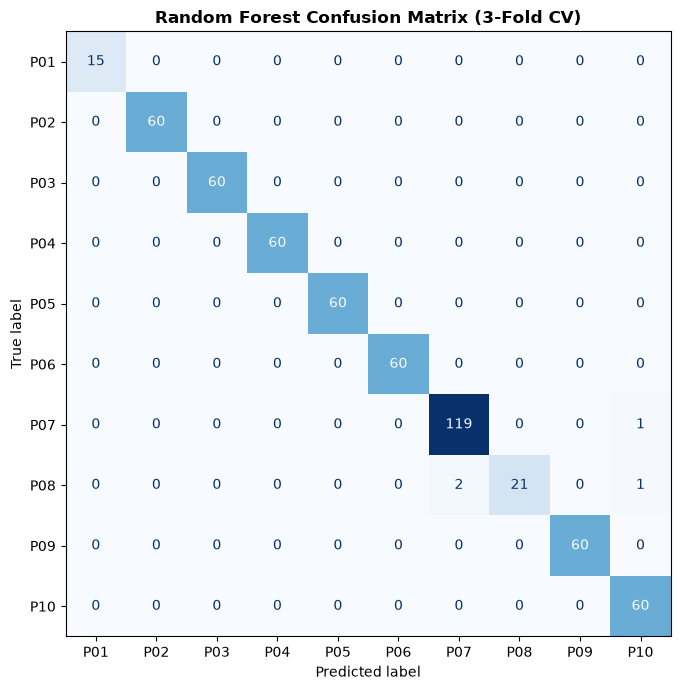

In [18]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("\n" + "=" * 60)
print("CONFUSION MATRIX: RANDOM FOREST (3-FOLD CV)")
print("=" * 60)

rf_cv_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=3,
    max_features='sqrt',
    random_state=42
)

cv_rf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
y_pred_rf_cv = cross_val_predict(rf_cv_model, X_all, y_all, cv=cv_rf)

cm_rf_cv = confusion_matrix(y_all, y_pred_rf_cv)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf_cv, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)
ax.set_title('Random Forest Confusion Matrix (3-Fold CV)', fontsize=12, fontweight='bold')
ax.grid(False)
plt.tight_layout()
plt.show()


FEATURE IMPORTANCE: RANDOM FOREST

Top 20 Most Important Features:
   1. Obj_Py_max                     0.0674
   2. Obj_Py_mean                    0.0477
   3. Obj_Py_min                     0.0393
   4. Head_Pz_mean                   0.0370
   5. Head_Px_min                    0.0350
   6. Head_Pz_max                    0.0337
   7. Right_Qx_mean                  0.0285
   8. Head_Pz_min                    0.0282
   9. Right_Ry_mean                  0.0276
  10. Left_Qz_max                    0.0275
  11. Right_Qx_max                   0.0267
  12. Head_Px_mean                   0.0198
  13. Right_Ry_min                   0.0184
  14. Head_Qz_mean                   0.0183
  15. Head_Ry_max                    0.0177
  16. Head_Px_max                    0.0167
  17. Left_Qz_mean                   0.0162
  18. Left_Qx_max                    0.0161
  19. Head_Qy_mean                   0.0157
  20. Head_Qx_min                    0.0153


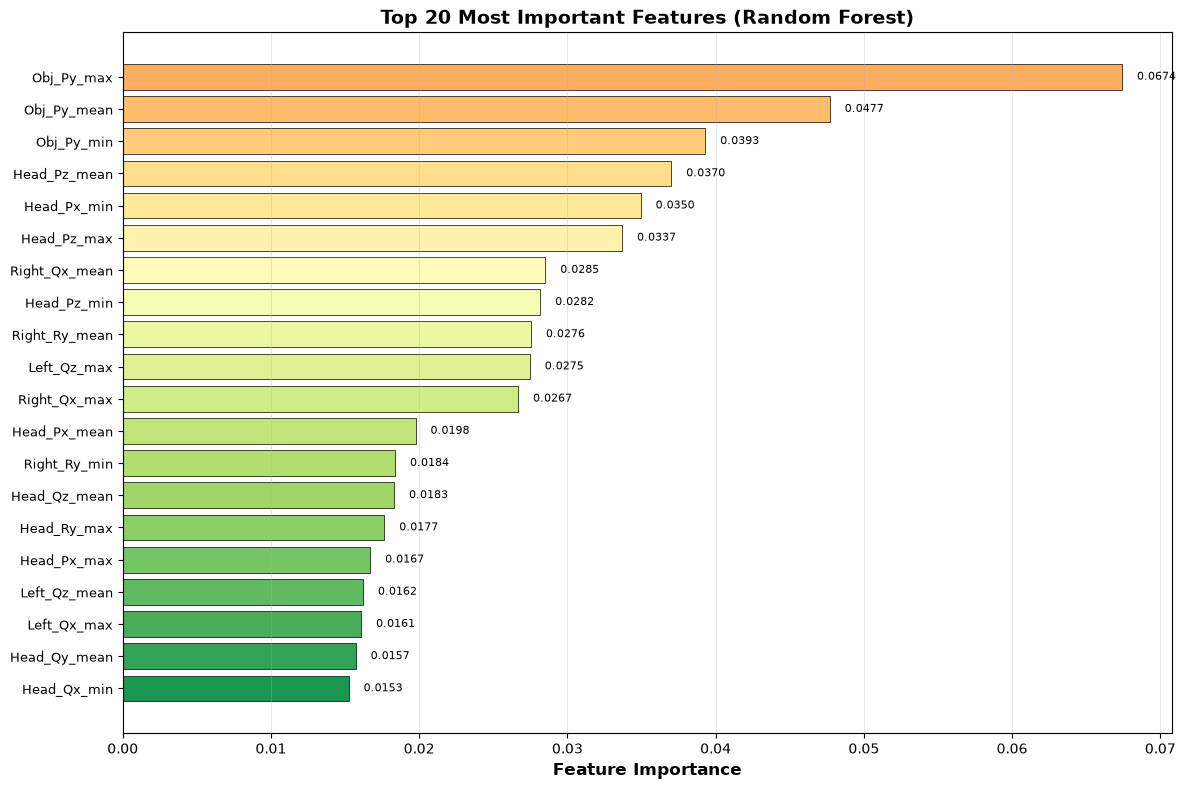

In [17]:
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE: RANDOM FOREST")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=3,
    max_features='sqrt',
    random_state=42
)
rf_model.fit(X_all, y_all)

feature_importance = rf_model.feature_importances_

sensor_names = list(feature_columns)
stat_names = ['min', 'max', 'mean', 'std']
feature_names = []
for sensor in sensor_names:
    for stat in stat_names:
        feature_names.append(f"{sensor}_{stat}")

top_n = 20
importance_indices = np.argsort(feature_importance)[-top_n:][::-1]
top_features = [feature_names[i] for i in importance_indices]
top_importance = feature_importance[importance_indices]

print(f"\nTop {top_n} Most Important Features:")
for i, (feat, imp) in enumerate(zip(top_features, top_importance), 1):
    print(f"  {i:2d}. {feat:<30s} {imp:.4f}")

# Visualize top features
fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, top_n))
bars = ax.barh(range(top_n), top_importance, color=colors, edgecolor='black', linewidth=0.5)

ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features, fontsize=9)
ax.set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
ax.set_title(f'Top {top_n} Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

for i, (bar, val) in enumerate(zip(bars, top_importance)):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()

## 5. Robust Evaluation Best Practices

This section adds stronger evaluation diagnostics for the Random Forest model:
- normalized confusion matrix (3-fold CV)
- per-class precision/recall/F1 from out-of-fold predictions
- fold-wise confusion matrices for stability analysis
- baseline comparison against a stratified dummy classifier

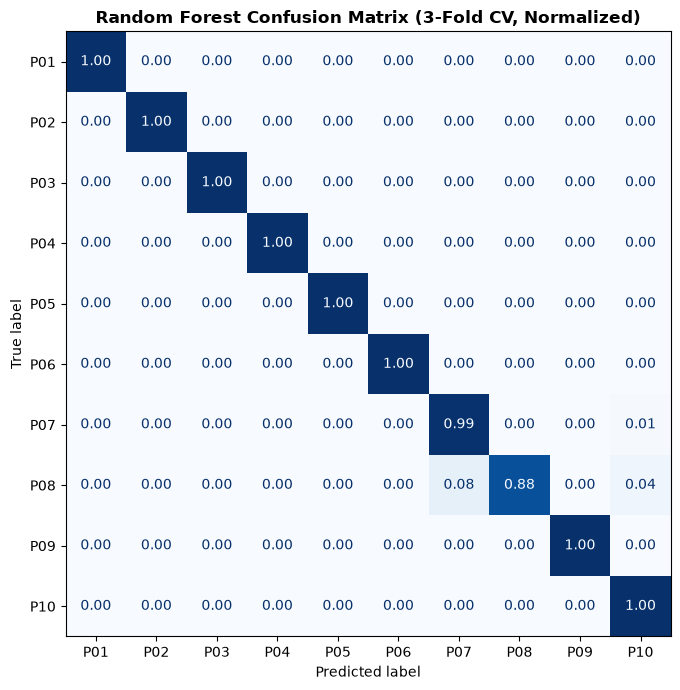

Per-class metrics (3-fold CV out-of-fold predictions):


,precision,recall,f1-score,support
P01,1.000,1.000,1.000,15.0
P02,1.000,1.000,1.000,60.0
P03,1.000,1.000,1.000,60.0
P04,1.000,1.000,1.000,60.0
P05,1.000,1.000,1.000,60.0
P06,1.000,1.000,1.000,60.0
P07,0.983,0.992,0.988,120.0
P08,1.000,0.875,0.933,24.0
P09,1.000,1.000,1.000,60.0
P10,0.968,1.000,0.984,60.0


In [19]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import pandas as pd

# Reuse RF CV predictions if they already exist; otherwise compute them.
if 'y_pred_rf_cv' not in globals():
    cv_rf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    rf_cv_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=3,
        max_features='sqrt',
        random_state=42
    )
    y_pred_rf_cv = cross_val_predict(rf_cv_model, X_all, y_all, cv=cv_rf)

# 1) Normalized confusion matrix (row-wise percentages)
fig, ax = plt.subplots(figsize=(8, 7))
disp_norm = ConfusionMatrixDisplay.from_predictions(
    y_all,
    y_pred_rf_cv,
    labels=np.arange(len(le.classes_)),
    display_labels=le.classes_,
    normalize='true',
    cmap='Blues',
    values_format='.2f',
    ax=ax,
    colorbar=False
    )
ax.set_title('Random Forest Confusion Matrix (3-Fold CV, Normalized)', fontsize=12, fontweight='bold')
ax.grid(False)
plt.tight_layout()
plt.show()

# 2) Per-class metrics table from out-of-fold predictions
report_dict = classification_report(
    y_all,
    y_pred_rf_cv,
    labels=np.arange(len(le.classes_)),
    target_names=le.classes_,
    output_dict=True,
    zero_division=0
    )
per_class_df = pd.DataFrame(report_dict).T
per_class_df = per_class_df.loc[le.classes_, ['precision', 'recall', 'f1-score', 'support']]
print('Per-class metrics (3-fold CV out-of-fold predictions):')
display(per_class_df.round(3))

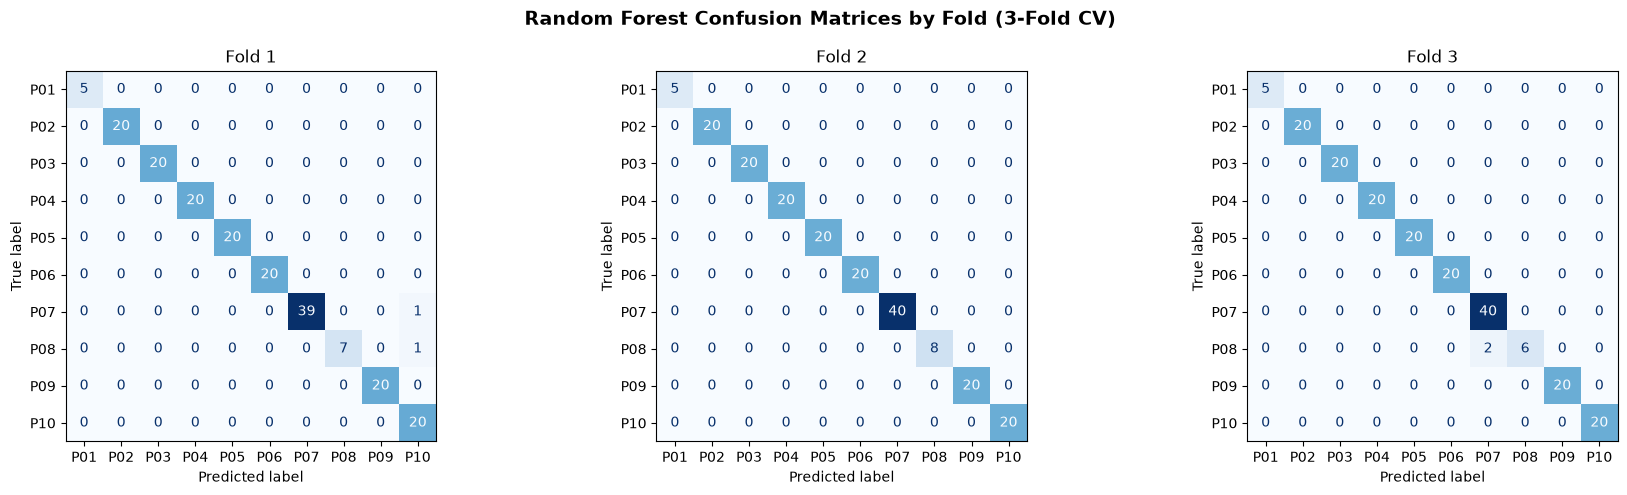

In [20]:
from sklearn.metrics import confusion_matrix

# 3) Fold-wise confusion matrices to inspect stability across folds
cv_rf_folds = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
rf_fold_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=3,
    max_features='sqrt',
    random_state=42
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for fold_idx, (train_idx, test_idx) in enumerate(cv_rf_folds.split(X_all, y_all), start=1):
    rf_fold_model.fit(X_all[train_idx], y_all[train_idx])
    fold_pred = rf_fold_model.predict(X_all[test_idx])
    cm_fold = confusion_matrix(y_all[test_idx], fold_pred, labels=np.arange(len(le.classes_)))
    disp_fold = ConfusionMatrixDisplay(confusion_matrix=cm_fold, display_labels=le.classes_)
    disp_fold.plot(cmap='Blues', values_format='d', ax=axes[fold_idx - 1], colorbar=False)
    axes[fold_idx - 1].set_title(f'Fold {fold_idx}')
    axes[fold_idx - 1].grid(False)

plt.suptitle('Random Forest Confusion Matrices by Fold (3-Fold CV)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

# 4) Baseline comparison: stratified dummy model vs Random Forest
baseline = DummyClassifier(strategy='stratified', random_state=42)
rf_ref = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=3,
    max_features='sqrt',
    random_state=42
    )

cv_eval = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
baseline_scores = cross_val_score(baseline, X_all, y_all, cv=cv_eval, scoring='accuracy')
rf_scores_cv = cross_val_score(rf_ref, X_all, y_all, cv=cv_eval, scoring='accuracy')

comparison_df = pd.DataFrame({
    'Model': ['Dummy (stratified)', 'Random Forest'],
    'Mean Accuracy': [baseline_scores.mean(), rf_scores_cv.mean()],
    'Std Accuracy': [baseline_scores.std(), rf_scores_cv.std()]
    })

print('Baseline vs Random Forest (3-fold CV):')
display(comparison_df.assign(
    **{
        'Mean Accuracy': lambda d: (d['Mean Accuracy'] * 100).round(2).astype(str) + '%',
        'Std Accuracy': lambda d: (d['Std Accuracy'] * 100).round(2).astype(str) + '%'
    }
))

Baseline vs Random Forest (3-fold CV):


,Model,Mean Accuracy,Std Accuracy
0,Dummy (stratified),8.98%,1.29%
1,Random Forest,99.31%,0.49%


## 6. Results (Final Summary)

### Cross-Validation Performance (3-Fold, Stratified)

| Model | Mean Accuracy | Std Dev |
|-------|---------------|---------|
| **Random Forest** | **99.31%** | **+/-0.49%** |
| Logistic Regression (scaled) | 98.79% | +/-0.49% |
| XGBoost | 98.45% | +/-0.42% |
| K-Nearest Neighbors | 95.34% | +/-0.42% |
| Dummy (stratified baseline) | 8.98% | +/-1.29% |

### Key Findings
1. Random Forest is the strongest model and is highly stable across folds.
2. Performance is far above the baseline, supporting strong identity signal in the movement features.
3. Most classes are predicted almost perfectly in 3-fold CV.
4. The main residual confusion is concentrated in a few classes (especially P08 with occasional confusion into P07/P10).

### Evaluation Quality Improvements Applied
- Rerun-safe preprocessing and pandas-3-compatible grouping logic.
- True out-of-fold confusion matrix for Random Forest (3-fold CV).
- Normalized confusion matrix and per-class metrics table.
- Fold-wise confusion matrices for stability checking.
- Baseline comparison with DummyClassifier.

### Limitations
1. The dataset remains relatively small for biometric generalization studies.
2. Feature dimensionality is high versus sample count, so optimistic estimates are still possible.
3. Validation is stratified CV, but not yet session-aware/group-aware CV.

### Future Work
1. Add GroupKFold or session-based validation when session IDs are available.
2. Add confidence intervals (e.g., bootstrap over predictions).
3. Export all evaluation tables and confusion matrices automatically for reporting.